
To serve the purpose of the Course work, I have selected the Titanic dataset available at kaggle. The challenge in this dataset is to develop a model that predicts if a person is going to survive the Titanic sinking accident or not (Thus, its a binary classification challenge). In next section we would open and print first 10 rows of the dataset followed by a brief data description.

In [1]:
#ignore warning
import warnings
warnings.filterwarnings('ignore')

#Getting the path to the data
import os
script_dir = os.path.dirname("__file__")
rel_path = "Titanic_train.csv"
file_path = os.path.join(script_dir, rel_path)

#Store data in data frame
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
df = pd.read_csv(file_path)
df[1:10]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Selection of Preprocessing techniques

It is clear from the above results that there are 11 attributes, of which 'Survived' attribute represents the classification label and has two possible set of values {1,0} denoting survived or not respectively.
For the remaining attributes, the datatype and required preprocessing are shown in the table below:


| Attribute   | Data type | Missing values | Prepocessing                         |
|-------------|-----------|----------------|--------------------------------------|
| PassengerID | Numerical | No             | Discard the column                   |
| Pclass      | Ordinal   | No             | n-of-m mapping                       |
| Name        | String    | No             | Discard the column                   |
| Sex         | Nominal   | No             | 1-of-n mapping                       |
| Age         | Numerical | Yes            | Discard the rows with missing values |
| SibSp       | Numerical | No             | None                                 |
| Parch       | Numerical | No             | None                                 |
| Ticket      | String    | No             | Discard the column                   |
| Fare        | Numerical | No             | None                                 |
| Cabin       | String    | Yes            | Discard the column                   |
| Embarked    | Ordinal   | No             | n-of-m mapping                       |

### Rationale behind selection of preprocessing techniques:
<ol>
    <li>PassengerId is a unique identifier and has no correlation with the class attribute.</li>
    <li>Pclass is a nominal attribute ,denoting the customers class using number 1, 2, and 3. To remove the ordering in this attribute we propose use of n of n mapping.</li>
    <li>Name attribute denotes a persons name, which has no correlation with the class attribute hence, I propose to discard the column as well.</li>
    <li>Sex is nominal in nature and SVM & Neutral network implementations cannot handle such data; so we propose use of 1-of-n mapping to remove the ordering that may be attained while converting them to numbers.</li>
    <li>Age attribute has 20% of values missing, and has no attribute with which it is correlated hence, we discard the rows with missing values.</li>
    <li>SibSp and Parch donot require anytype of preprocessing, these attributes represent presence of siblings ,children, and parents.</li>
    <li>Ticket attribute is another unique identifier with no correlation with class attribute, hence we discard the same.</li>
    <li>Embarked is an ordinal attribute representing the orgin station of the customer however, it has two missing values which are missing completely at random. A proof of this is available in Appendix A. Hence, we fill it using random variable.</li>
    <li>Cabin attribute has more than 77% values missing. Hence, we discard this column. A proof of the same is attached below which enlists all attributes with the percentage of missing values.</li>
 <ol>

In [2]:
# Data Charctiristcs and Data Description types 

df.shape

(891, 12)

In [3]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [4]:
#percentage of missing values 
print("\nAttributes and Missing values (in percentage)")
df.isnull().sum()/len(df)*100


Attributes and Missing values (in percentage)


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

### Preprocessing the data
<b>Please note:</b> after each step in preprocessing, we update the name of dataframe with the recursive nomencleature of "df_v(I)". Where 'I' denotes the version number of data frame as well as denote the latest updated version of data after each step. This was used to make preprocessing step more understandable.

<b>Step 1:</b> First we remove the unwanted data columns, either, Name, PassengerID, Cabin, and Ticket and store the results in df_v1.

In [5]:
cols = [col for col in df.columns if col not in ['PassengerId', 'Ticket', 'Cabin', 'Name']]
df_v1 = df[cols]
df_v1[0:2]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C


<b>Step 2:</b> We treat the missing values in 'Embarked attribute'. 
Embarked represents, the port from which customer boarded. Only two values are missing in this column as shown in the next cell. And both of these are missing completely at random, since Embarked attribute has relation with Fare and Pclass. We figure out that the probability of having boarded from point 'Q' is 0% and 'S' and 'C' it is same at around 50%. The same has been depicted in the histogram obtained after selecting the rows similar to the ones with null values. The final results would be stored in variable df_v2.

In [6]:
#Printing rows with missing values
df[df_v1['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


It is clear that the missing values had a dependency on Cabin type (First letter in Cabin), Fare and Pclass. Hence we try to prove our hypothesis before filling with missing values. 

<AxesSubplot:title={'center':'Distribution of classes for rows similar to the ones with missing values'}>

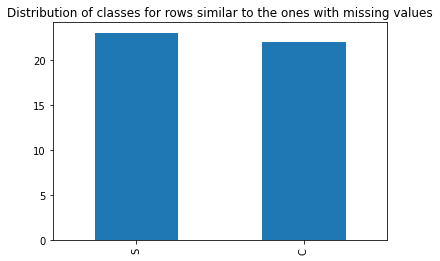

In [7]:
#Few temporary variables accessing data from the original data frame df, to select similar rows
dfv = df.loc[df['Cabin'].astype(str).str[0] == 'B'] # both the mising values have cabin letter 'B'. Either they are on same deck.
dfv1 = dfv #temporary variable to keep a copy of data safe
dfv1.loc[dfv['Pclass']==1] #To make data similar for the same class.
dfv1.loc[dfv['Fare']==80] #To make the fare range same for similarity of rows.

dfv['Embarked'].value_counts().plot(kind="bar",title="Distribution of classes for rows similar to the ones with missing values") # To visualize the distribution of classes for similar rows 


From the above bar graph it is clear that, there is equal probability of the customers origin port being either 'S' or 'C'. And since they are equal likely, for both of these values, it means that data is missing randomly and the Embarked has no relationship with Fare and Pclass, as stated earlier in the hypothesis. Hence, we fill these values randomly. Finally we store the updated values in df_v2.

In [8]:
#Random number generation and comparison if random no > 5, Embarked value is 'C' otherwise 'S'
import numpy.random as r
d=r.randint(0,10)
if(d>5):
    df_v1['Embarked'][61]='C'
    df_v1['Embarked'][829]='C'
else:
    df_v1['Embarked'][61]='S'
    df_v1['Embarked'][829]='S'
df_v2 = df_v1.copy()

Thus, both the values have been filled with random values. Here we use one random number to fill both the values since ticket number for both is same which, means that they embarked from the same port.

<b>Step 3:</b> Here we treat attribute 'Age' and remove all rows with missing values. And once done we store the results in df_v3.

In [9]:
df_v3= df_v2.dropna()
print("\nAttributes and Missing values (in percentage)")
df_v3.isnull().sum()/len(df_v3)*100


Attributes and Missing values (in percentage)


Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Embarked    0.0
dtype: float64

Thus all the missing values have been handles.

<b>Step 4:</b> Now we deal with ordinal data Gender and use one-of-n mapping for the purpose of convering the data. Finally we will store the data in df_v4.

In [10]:
df_v4 = df_v3.copy()
df_v4 = df_v4.assign(male=0) #set default values to 0 denoting that its not a male
df_v4 = df_v4.assign(female=0) #set default values to 0 denoting that its not a female
for row_index,row in df_v4.iterrows():
    if str(row.Sex)=="male":
        df_v4['male'][row_index]=1
    else:
        df_v4['female'][row_index]=1

del df_v4['Sex'] #Delete the Ordinal column Sex from the data set
df_v4[0:2] #Display five rows to verify that the script works correctly.

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,male,female
0,0,3,22.0,1,0,7.2500,S,1,0
1,1,1,38.0,1,0,71.2833,C,0,1


<b>Step 5:</b> In this step we treat both the nomial attributes 'Pclass' and 'Embarked'. Both of these have three set of values {1,2,3} and {'S','C','Q'} and store the results in df_v5.

In [11]:
df_v5 = df_v4.copy()
# N-of-M mapping for Embarked
df_v5 = df_v5.assign(c=0) 
df_v5 = df_v5.assign(q=0) 
df_v5 = df_v5.assign(s=0) 

for row_index,row in df_v5.iterrows():
    if str(row.Embarked)=='C':
        df_v5['c'][row_index]=1
    elif str(row.Embarked)=='Q':
        df_v5['q'][row_index]=1
    else:
        df_v5['s'][row_index]=1

del df_v5['Embarked'] 
df_v5[0:2]

,Survived,Pclass,Age,SibSp,Parch,Fare,male,female,c,q,s
0,0,3,22.0,1,0,7.2500,1,0,0,0,1
1,1,1,38.0,1,0,71.2833,0,1,1,0,0


In [12]:
# N-of-M mapping for Pclass
df_v5 = df_v5.assign(pclass1=0) 
df_v5 = df_v5.assign(pclass2=0) 
df_v5 = df_v5.assign(pclass3=0) 

for row_index,row in df_v5.iterrows():
    if str(df_v5['Pclass'][row_index])=='1':
        df_v5['pclass1'][row_index]=1
    elif str(df_v5['Pclass'][row_index])=='2':
        df_v5['pclass2'][row_index]=1
    else:
        df_v5['pclass3'][row_index]=1

del df_v5['Pclass'] 


df_v5[0:10] #Display five rows to verify that the script works correctly.

,Survived,Age,SibSp,Parch,Fare,male,female,c,q,s,pclass1,pclass2,pclass3
0,0,22.0,1,0,7.2500,1,0,0,0,1,0,0,1
1,1,38.0,1,0,71.2833,0,1,1,0,0,1,0,0
2,1,26.0,0,0,7.9250,0,1,0,0,1,0,0,1
3,1,35.0,1,0,53.1000,0,1,0,0,1,1,0,0
4,0,35.0,0,0,8.0500,1,0,0,0,1,0,0,1
6,0,54.0,0,0,51.8625,1,0,0,0,1,1,0,0
7,0,2.0,3,1,21.0750,1,0,0,0,1,0,0,1
8,1,27.0,0,2,11.1333,0,1,0,0,1,0,0,1
9,1,14.0,1,0,30.0708,0,1,1,0,0,0,1,0
10,1,4.0,1,1,16.7000,0,1,0,0,1,0,0,1


### Visualization 1: 
In next visualization we focus on identifying the correlation between Passenger class and survival.

<AxesSubplot:xlabel='Pclass', ylabel='count'>

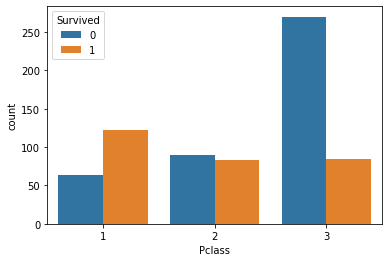

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
dfv1 = df_v3.copy()
sns.countplot(x='Pclass', hue='Survived', data=dfv1)

From this visualization it can be inferred that there was high chance of not surviving if you had been in the 3rd class.

### Visualization 2: 
Here, we draw a density plot of the class attribute 'Survived'. So as to infer if there is a class imbalance. Class imbalance is a major problem is there are not enough data points for a class.

<AxesSubplot:ylabel='Density'>

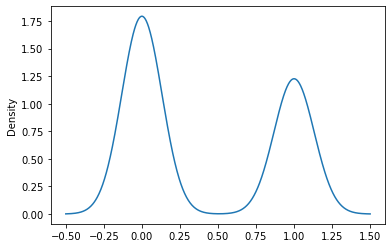

In [14]:
df_v5['Survived'].plot.density()

From the density plot it is clear that composition of the classes in the dataset in nearly 2:1. Now there are more than 800 data points in the dataset, hence there is enough data points for each class. Thus, we do not need to perform any form of data sampling.

### Visualization 3:
In the following visualization we plan to figure out the relation between Pclass, Cabin block (First letter in Cabin attribute), and Fare. The purpose of this visualization was to help preporcess, the missing values in Embarked attribute. The choice of attribute was based on similarity of the two missing rows, both of which belonged to same passenger class and paid same amount of fare.

<AxesSubplot:xlabel='Pclass', ylabel='Fare'>

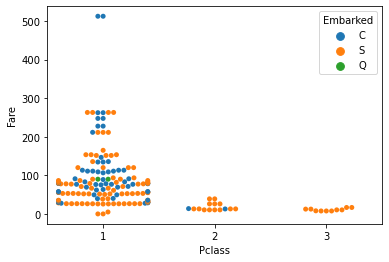

In [15]:
dvs2 = df.dropna()
dvs2 = dvs2.assign(cab=df['Cabin'].astype(str).str[0])
sns.swarmplot(x='Pclass',y='Fare',hue='Embarked',data=dvs2)

Now attribute values for the missing rows were, Fare = 80.0 and Pclass = 1. A peep into visualization at these values gives a clear inference that, the port of embarkment was definitely not 'Q'. The choice between 'C' and 'S' is completely at random and independent of any choice. A bar graph representing the probability of 'C' and 'S' has been plotted in the Preprocessing step of Embarkment. 

### Visualization 4:
Here we try to visualize the relation between attributes 'Age' and class variable 'Survived' to find if there exists any form of correlation.

<AxesSubplot:title={'center':'Age'}, xlabel='Survived'>

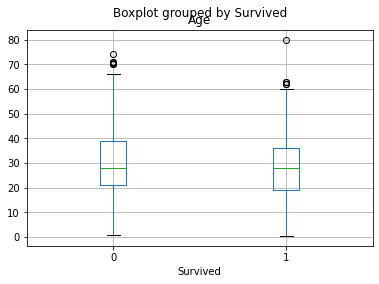

In [16]:
dfv3 = df_v3.copy()
dfv3.boxplot(column='Age', by='Survived')

The following Box plot suggest that passengers with age more than 60 had rare chances of survival.

### Visualization 5: 
Our hypothesis for this visualization is to find the relation between Parch and Survival. This graph gives information of how many people who had either their parents or children onboard with them survived.


<AxesSubplot:xlabel='Parch', ylabel='count'>

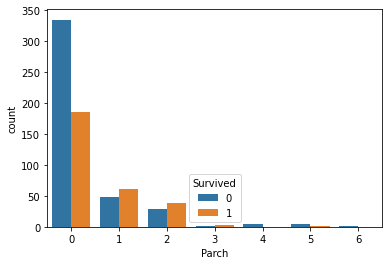

In [17]:
dfv1 = df_v3.copy()
sns.countplot(x='Parch', hue='Survived', data=dfv1)

From the graph it is clear that probability of survival was 40% more for those travellers who didnot has parents or children on board.

For the purpose of developing a prediction model. We split the dataset using 10-fold cross validation. And use Decision Tree, Neutral Network, and SVM to train the model.
The next segment of code is written to split into to training and testing data. 

In [18]:
from sklearn.model_selection import train_test_split
df_v6 = df_v5.copy()
del df_v6['Survived']
X_train, X_test, y_train, y_test = train_test_split(df_v6, df_v5.Survived, test_size=0.1, random_state=0)

To make it easy, the following code section implements a small function that prints Precision and Recall.

In [19]:
def pre_rec(y_test,y_predict,labelss):
    from sklearn.metrics import confusion_matrix
    a = confusion_matrix(y_test,y_predict, labels= labelss)
    recall = a[0][0]/(a[0][0]+a[0][1])
    precision = a[0][0]/(a[0][0]+a[1][0])
    return precision,recall

### Model 1: Decision Tree Model

In [20]:
#Learning a Decision Tree with default parameters
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
x1_predict = dt.predict(X_test)
p_dt, r_dt = pre_rec(y_test,x1_predict,[0,1])

In [21]:
from sklearn.metrics import confusion_matrix
a=confusion_matrix(y_test,x1_predict)
accuracy_dt=(a[0][0]+a[1][1])/(a[0][0]+a[0][1]+a[1][0]+a[1][1])
print("\nAccuracy: "+str(accuracy_dt))


Accuracy: 0.6527777777777778


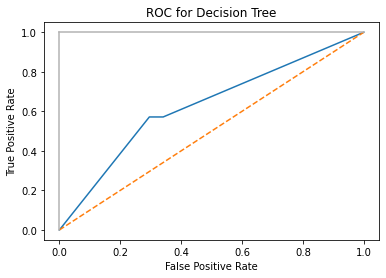

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score
# Get predicted probabilities
y_score = dt.predict_proba(X_test)[:,1]
# Create true and false positive rates
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test, y_score)
# Plot ROC curve
plt.title('ROC for Decision Tree')
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Model 2: Random Forest

In [23]:
#Learning a RandomForestClassifier with default parameters
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
x1_predict = rf.predict(X_test)
p_rf, r_rf = pre_rec(y_test,x1_predict,[0,1])

In [24]:
a=confusion_matrix(y_test,x1_predict)
accuracy_rf=(a[0][0]+a[1][1])/(a[0][0]+a[0][1]+a[1][0]+a[1][1])
print("\nAccuracy: "+str(accuracy_rf))


Accuracy: 0.7638888888888888


### Model 3: XGBoost

In [25]:
from xgboost import XGBClassifier
xb = XGBClassifier()
xb.fit(X_train,y_train)
x1_predict = xb.predict(X_test)
p_xb, r_xb = pre_rec(y_test,x1_predict,[0,1])

[05:36:52] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [26]:
a=confusion_matrix(y_test,x1_predict)
accuracy_xb=(a[0][0]+a[1][1])/(a[0][0]+a[0][1]+a[1][0]+a[1][1])
print("\nAccuracy: "+str(accuracy_xb))


Accuracy: 0.7638888888888888


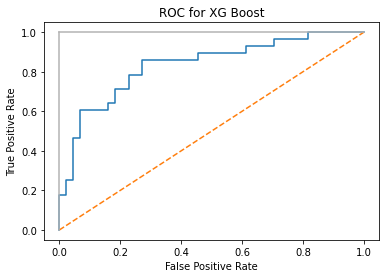

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
# Get predicted probabilities
y_score = xb.predict_proba(X_test)[:,1]
# Create true and false positive rates
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test, y_score)
# Plot ROC curve
plt.title('ROC for XG Boost')
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

### Model 4: Neural Network Model

In [28]:
#Learning a Neural Network with default parameters
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier()
mlp.fit(X_train,y_train)
x1_predict = mlp.predict(X_test)
p_nn,r_nn = pre_rec(y_test,x1_predict,[0,1])

In [29]:
a=confusion_matrix(y_test,x1_predict)
accuracy_nn=(a[0][0]+a[1][1])/(a[0][0]+a[0][1]+a[1][0]+a[1][1])
print("\nAccuracy: "+str(accuracy_nn))


Accuracy: 0.7916666666666666


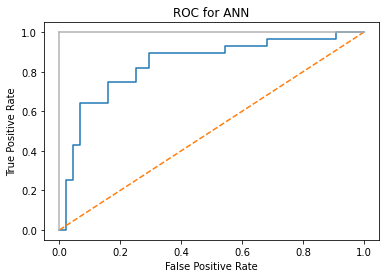

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
# Get predicted probabilities
y_score = mlp.predict_proba(X_test)[:,1]
# Create true and false positive rates
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test, y_score)
# Plot ROC curve
plt.title('ROC for ANN')
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


In [31]:
### ROC For ANN Interpretation

### Model 5: SVM Model

In [32]:
#SVM Learning with default parameters
from sklearn import svm
svvm = svm.SVC()
svvm.fit(X_train,y_train)
x1_predict = svvm.predict(X_test)
p_svm,r_svm = pre_rec(y_test,x1_predict,[0,1])

In [33]:
a=confusion_matrix(y_test,x1_predict)
accuracy_svm=(a[0][0]+a[1][1])/(a[0][0]+a[0][1]+a[1][0]+a[1][1])
print("\nAccuracy: "+str(accuracy_svm))


Accuracy: 0.6527777777777778


In [37]:
print("Classifier \t\t Precision \t\t\t Recall \t\t\tAccuracy")
print("---------------------------------------------------------------------------------------------------------")
print("\nDecision Tree \t\t "+str(p_dt)+" \t\t"+str(r_dt)+" \t\t"+str(accuracy_dt))
print("\nRandom Forest \t\t "+str(p_rf)+" \t\t\t\t"+str(r_rf)+" \t\t"+str(accuracy_rf))
print("\nXG Boost \t\t "+str(p_xb)+" \t\t"+str(r_xb)+" \t\t"+str(accuracy_xb))
print("\nSVM \t\t\t "+str(p_svm)+" \t\t"+str(r_svm)+" \t\t"+str(accuracy_svm))
print("\nNeural Network \t\t "+str(p_nn)+" \t \t"+str(r_nn)+" \t \t"+str(accuracy_nn))

Classifier 		 Precision 			 Recall 			Accuracy
---------------------------------------------------------------------------------------------------------

Decision Tree 		 0.7209302325581395 		0.7045454545454546 		0.6527777777777778

Random Forest 		 0.8 				0.8181818181818182 		0.7638888888888888

XG Boost 		 0.813953488372093 		0.7954545454545454 		0.7638888888888888

SVM 			 0.6792452830188679 		0.8181818181818182 		0.6527777777777778

Neural Network 		 0.8222222222222222 	 	0.8409090909090909 	 	0.7916666666666666


### Interpretation of Evalution:

From repeating the process multiple times of training and testing different models it was found that Neural Network was the best model with default parameters for all the selected models. While the Decision tree produced the lowest results among all three algorithms as seen in the evaluation table and ROC curve in the above images. ROC curve is plotted for the Decision tree, Xgbosst, and ANN to support the model accuracy. In the above figure, it is clearly seen that the ROC curve for ANN is closer to the top left corner in comparison to XGboost and Decision tree. ROC for the Decision tree is far away from the top left corner and ROC for XGBoost lies closer to the ANN ROC curve.

### Conclusion:
The decision tree performed the least accurate because it always tried to draw margins parallel to the axis, SVM failed to be the best performer, since it tried to fit a linear model over non-linearly separable data. Finally, Neural Network trained the best model, since it allowed the best combination of all the attributes to be used for the calculation of node values in hidden stages. This is also confirmed by the highest accuracy of 79% and ROC curve to the left-most corner of the graph for ANN.